# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Anisa Hayatullah
- **Email:** m001b4kx0562@bangkit.academy
- **ID Dicoding:** anisahayatullah

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: What are the behaviors, carachteristic, transaction patterns of customers, particularly those with active orders, in relation to payment methods and product categories on the e-commerce platform?
- Pertanyaan 2: What are the observed trends and patterns in sales growth across various product categories within the e-commerce sector during the specified analysis period?
- When did the customer last make a transaction?
- How often has a customer made a purchase in the last few months?
- How much money did the customer spend in the last few months?

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install gdown

In [2]:
import gdown
import zipfile
import logging
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import re
import missingno as msno
from babel.numbers import format_currency

## Data Wrangling

### Gathering Data

#####LOAD THE DATASET

In [3]:
def download_data(url, filename) -> None:
    logging.info("Downloading data....")

    # Download the zip file from Google Drive
    gdown.download(url, quiet=False)

    logging.info("Extracting zip file....")

    # Extract the zip file to the current working directory
    with zipfile.ZipFile(f"{filename}.zip", 'r') as zip_ref:
        zip_ref.extractall()  # Extract to the current directory

    # Remove the zip file after extraction
    os.remove(f"{filename}.zip")

# Example usage
download_data(url="https://drive.google.com/uc?id=1xgtHxJ2hAECxt00HzBHGo_8POlc17JDW",
              filename="Brazilian E-Commerce Public Dataset by Olist")


Downloading...
From (original): https://drive.google.com/uc?id=1xgtHxJ2hAECxt00HzBHGo_8POlc17JDW
From (redirected): https://drive.google.com/uc?id=1xgtHxJ2hAECxt00HzBHGo_8POlc17JDW&confirm=t&uuid=25222e94-27d6-47b9-a4c3-889410c7662c
To: /content/Brazilian E-Commerce Public Dataset by Olist.zip
100%|██████████| 44.7M/44.7M [00:01<00:00, 22.8MB/s]


In [4]:
olist_customers_dataset = pd.read_csv('olist_customers_dataset.csv')
olist_order_items_dataset = pd.read_csv('olist_order_items_dataset.csv')
olist_order_payments_dataset = pd.read_csv('olist_order_payments_dataset.csv')
olist_orders_dataset = pd.read_csv('olist_orders_dataset.csv')
olist_products_dataset = pd.read_csv('olist_products_dataset.csv')
olist_sellers_dataset = pd.read_csv('olist_sellers_dataset.csv')
product_category_name_translation = pd.read_csv('product_category_name_translation.csv')

In [5]:
df_order = olist_orders_dataset.merge(olist_order_items_dataset, how="left", on="order_id").merge(
    olist_order_payments_dataset, how="left", on="order_id").merge(
    olist_products_dataset, how="left", on="product_id").merge(
    olist_sellers_dataset, how="left", on="seller_id").merge(
    product_category_name_translation, how="left", on="product_category_name")

df_order = olist_customers_dataset.merge(df_order, how="left", on="customer_id")

In [ ]:
df_order.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1141.0,1.0,8683.0,54.0,64.0,31.0,8577.0,itaquaquecetuba,SP,office_furniture
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1002.0,3.0,10150.0,89.0,15.0,40.0,88303.0,itajai,SC,housewares
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,955.0,1.0,8267.0,52.0,52.0,17.0,8577.0,itaquaquecetuba,SP,office_furniture
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1066.0,1.0,12160.0,56.0,51.0,28.0,8577.0,itaquaquecetuba,SP,office_furniture
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,407.0,1.0,5200.0,45.0,15.0,35.0,14940.0,ibitinga,SP,home_confort


In [ ]:
df_order.shape[0]

118434

In [ ]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    118434 non-null  object 
 1   customer_unique_id             118434 non-null  object 
 2   customer_zip_code_prefix       118434 non-null  int64  
 3   customer_city                  118434 non-null  object 
 4   customer_state                 118434 non-null  object 
 5   order_id                       118434 non-null  object 
 6   order_status                   118434 non-null  object 
 7   order_purchase_timestamp       118434 non-null  object 
 8   order_approved_at              118258 non-null  object 
 9   order_delivered_carrier_date   116360 non-null  object 
 10  order_delivered_customer_date  115037 non-null  object 
 11  order_estimated_delivery_date  118434 non-null  object 
 12  order_item_id                 

**Insight:**
- This merged dataset has 118434 records of user order data
- This dataset has 34 columns
- This dataset was joined with the 'left' join method which means it retains all the records of the left-hand table

### Assessing Data

####Understand the metadata and data

In [ ]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    118434 non-null  object 
 1   customer_unique_id             118434 non-null  object 
 2   customer_zip_code_prefix       118434 non-null  int64  
 3   customer_city                  118434 non-null  object 
 4   customer_state                 118434 non-null  object 
 5   order_id                       118434 non-null  object 
 6   order_status                   118434 non-null  object 
 7   order_purchase_timestamp       118434 non-null  object 
 8   order_approved_at              118258 non-null  object 
 9   order_delivered_carrier_date   116360 non-null  object 
 10  order_delivered_customer_date  115037 non-null  object 
 11  order_estimated_delivery_date  118434 non-null  object 
 12  order_item_id                 

**Insight:**
- Some columns with date format do not have datetime data type

####Identify Missing Value

In [ ]:
df_order.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0
order_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,176
order_delivered_carrier_date,2074


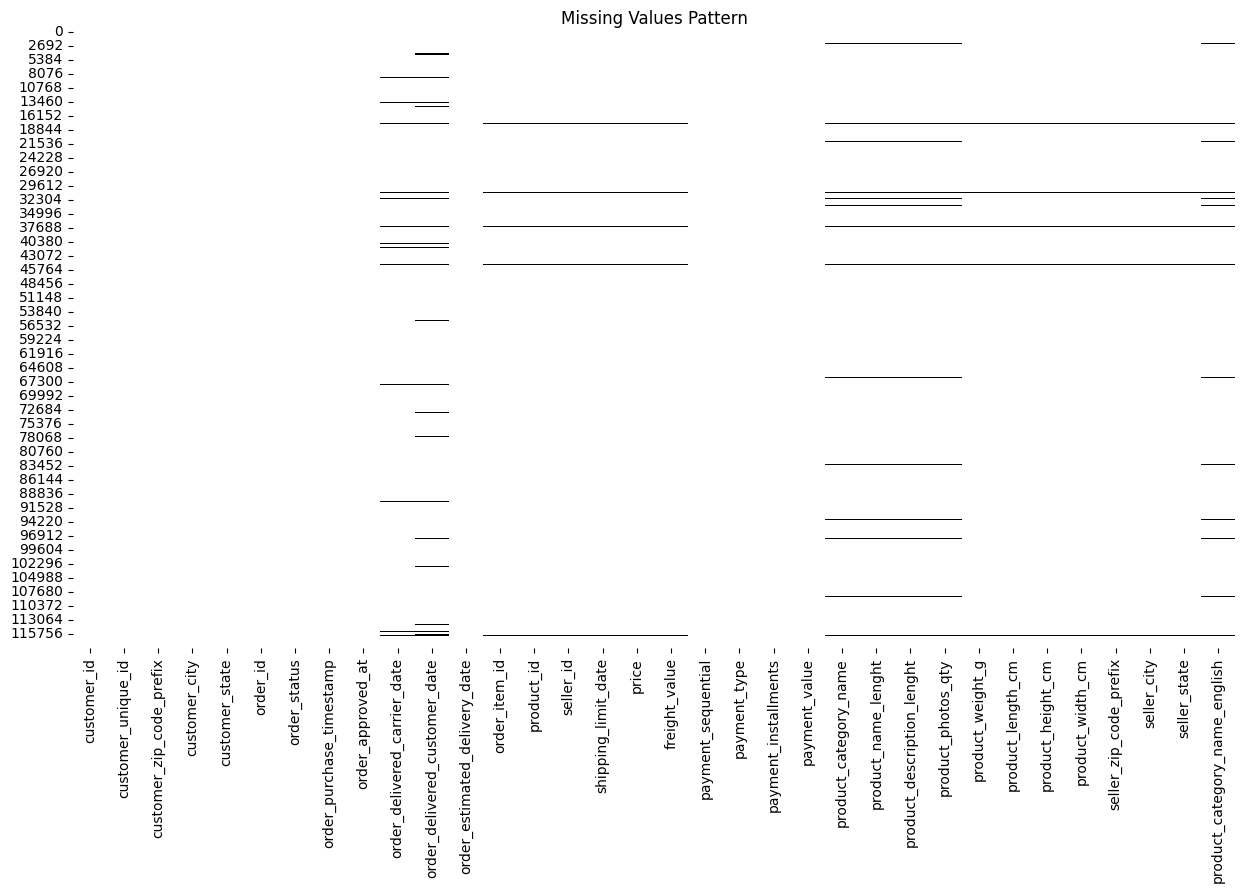

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_order.isnull(), cbar=False, cmap='binary')
plt.title('Missing Values Pattern')
plt.show()

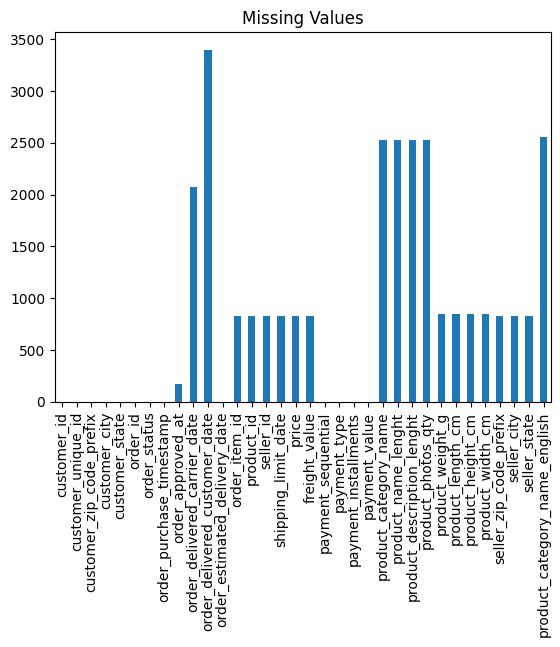

In [ ]:
df_order.isnull().sum().plot(kind='bar')
plt.title('Missing Values')
plt.show()

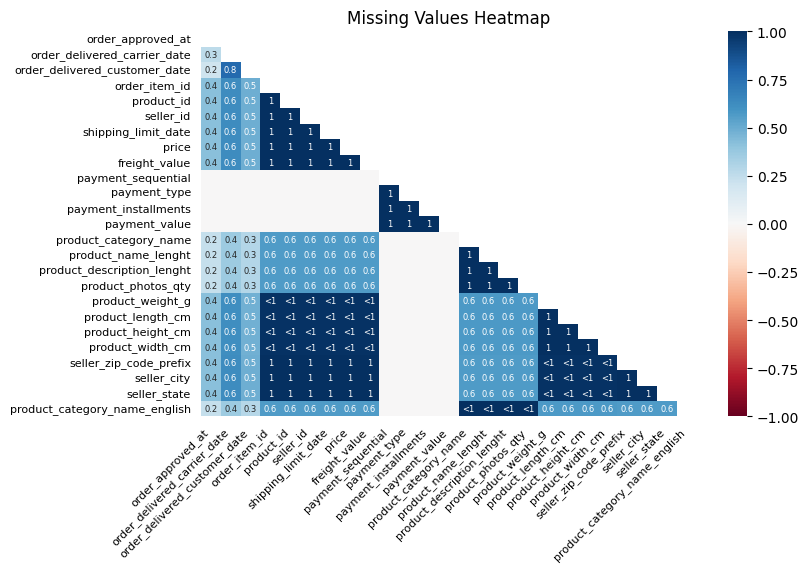

In [ ]:
msno.heatmap(df_order, figsize=(8, 5), fontsize = 8)
plt.title('Missing Values Heatmap')
plt.show()


**Insight:**
- Most Null values relate to the time (date) the order was confirmed to be received as well as the product description.
- In some cases when values related to the time of order are identified as null, the product description and seller are often also null
- The number of nulls in product_category_name is equal to product_category_name_english which indicates each product_category_name has an English name.
- Some missing values have a large correlation value, which indicates that there is a relationship between a missing value in one column having an impact on another column.

####Identify Duplicated Value

In [ ]:
print("Number of Duplicate: ", df_order.duplicated().sum())

Number of Duplicate:  0


- No data duplication, meaning all data is unique

####Logical Validation

In [ ]:
df_order.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,118434,99441,270c23a11d024a44c896d1894b261a83,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,118434,96096,9a736b248f67d166d2fbb006bcb877c3,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,118434.0,NaN,NaN,NaN,35034.264392,29819.290218,1003.0,11310.0,24240.0,58464.5,99990.0
customer_city,118434,4119,sao paulo,18738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,118434,27,SP,49967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,118434,99441,895ab968e7bb0d5659d16cd74cd1650c,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,118434,8,delivered,115038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,118434,98875,2017-08-08 20:26:31,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_approved_at,118258,90733,2017-08-08 20:43:31,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,116360,81018,2017-08-10 11:58:14,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_order.describe(include='object').T

,count,unique,top,freq
customer_id,118434,99441,270c23a11d024a44c896d1894b261a83,63
customer_unique_id,118434,96096,9a736b248f67d166d2fbb006bcb877c3,75
customer_city,118434,4119,sao paulo,18738
customer_state,118434,27,SP,49967
order_id,118434,99441,895ab968e7bb0d5659d16cd74cd1650c,63
order_status,118434,8,delivered,115038
order_purchase_timestamp,118434,98875,2017-08-08 20:26:31,63
order_approved_at,118258,90733,2017-08-08 20:43:31,63
order_delivered_carrier_date,116360,81018,2017-08-10 11:58:14,63
order_delivered_customer_date,115037,95664,2017-08-14 12:46:18,63


In [ ]:
df_order.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,118434.0,35034.264392,29819.290218,1003.00,11310.00,24240.00,58464.500,99990.00
order_item_id,117604.0,1.195920,0.697721,1.00,1.00,1.00,1.000,21.00
price,117604.0,120.822849,184.477367,0.85,39.90,74.90,134.900,6735.00
freight_value,117604.0,20.045551,15.861351,0.00,13.08,16.29,21.190,409.68
payment_sequential,118431.0,1.094207,0.728290,1.00,1.00,1.00,1.000,29.00
payment_installments,118431.0,2.937398,2.774164,0.00,1.00,2.00,4.000,24.00
payment_value,118431.0,172.849395,268.259831,0.00,60.86,108.20,189.245,13664.08
product_name_lenght,115906.0,48.767208,10.035162,5.00,42.00,52.00,57.000,76.00
product_description_lenght,115906.0,786.957302,653.029009,4.00,347.00,601.00,985.000,3992.00
product_photos_qty,115906.0,2.207849,1.719519,1.00,1.00,1.00,3.000,20.00


In [ ]:
# Count null values in each column for each order_status
null_counts = df_order.groupby("order_status").apply(lambda x: x.isnull().sum())
null_counts.T

<ipython-input-21-6bc4b349f8e2>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_counts = df_order.groupby("order_status").apply(lambda x: x.isnull().sum())


order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
customer_id,0,0,0,0,0,0,0,0
customer_unique_id,0,0,0,0,0,0,0,0
customer_zip_code_prefix,0,0,0,0,0,0,0,0
customer_city,0,0,0,0,0,0,0,0
customer_state,0,0,0,0,0,0,0,0
order_id,0,0,0,0,0,0,0,0
order_status,0,0,0,0,0,0,0,0
order_purchase_timestamp,0,0,0,0,0,0,0,0
order_approved_at,0,156,5,15,0,0,0,0
order_delivered_carrier_date,3,666,5,2,373,375,0,650


**Insight**
- although all records are unique, there were only 99441 orders in the time span
- no negative items indicates that all values are valid (variables cannot have negative values)
- null values in some variables are caused by order_status, for example canceled, so the data will not have the variable order_delivered_customer_date

####Identify Outlier

Show histogram for all numeric columns


In [ ]:
df_order.shape[0]

118434

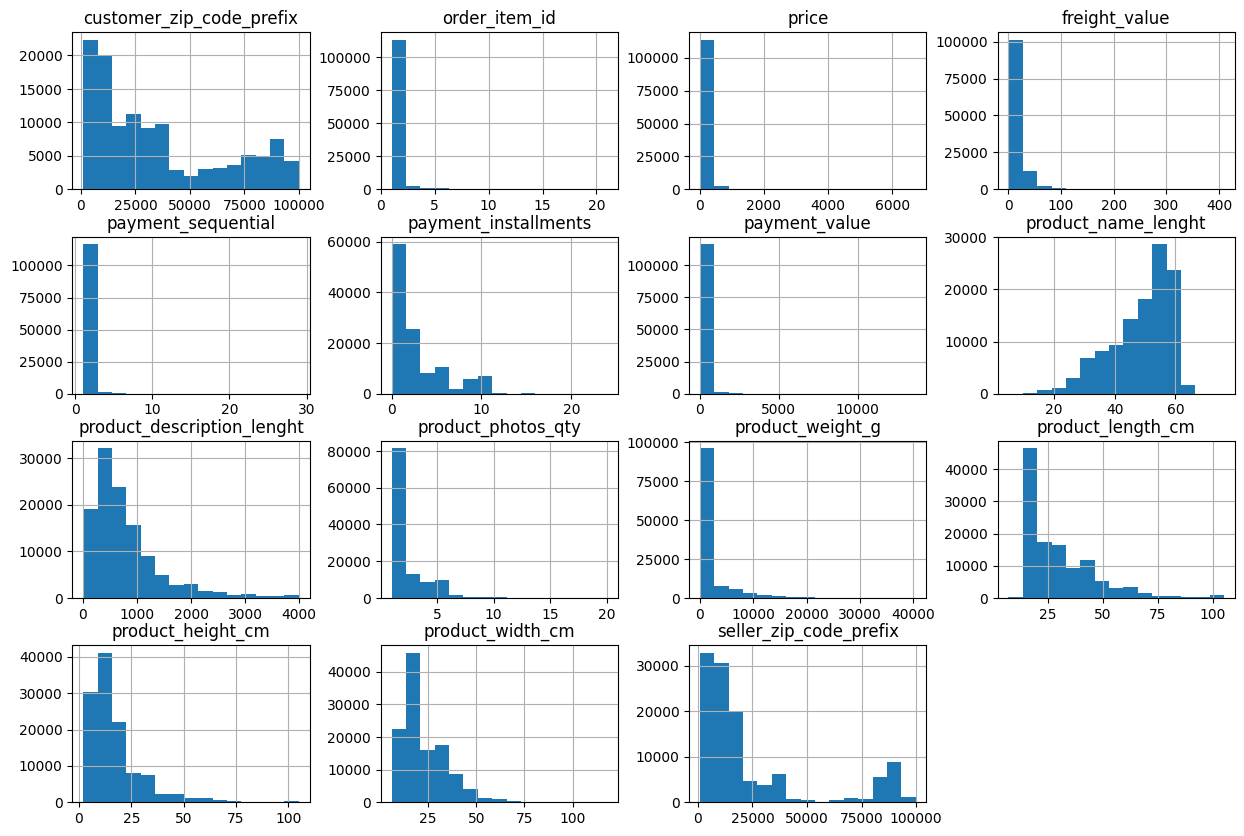

In [ ]:
df_order.hist(bins=15, figsize=(15, 10))
plt.show()


In [ ]:
for coloumn in df_order.select_dtypes(include=['number']).columns:
    data = df_order[coloumn].dropna()
    q25, q75 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q75 - q25
    cut_off = iqr * 1.5
    minimum, maximum = q25 - cut_off, q75 + cut_off

    # Use boolean indexing to find outliers
    outlier = data[(data < minimum) | (data > maximum)].tolist()
    outliers = len(outlier)
    print(f'Number of outliers for {coloumn}: {outliers}')

Number of outliers for customer_zip_code_prefix: 0
Number of outliers for order_item_id: 14547
Number of outliers for price: 8844
Number of outliers for freight_value: 12683
Number of outliers for payment_sequential: 5099
Number of outliers for payment_installments: 8066
Number of outliers for payment_value: 9580
Number of outliers for product_name_lenght: 802
Number of outliers for product_description_lenght: 7336
Number of outliers for product_photos_qty: 3198
Number of outliers for product_weight_g: 16630
Number of outliers for product_length_cm: 3805
Number of outliers for product_height_cm: 8066
Number of outliers for product_width_cm: 2740
Number of outliers for seller_zip_code_prefix: 18099


In [ ]:
df_order.shape[1]

34

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.

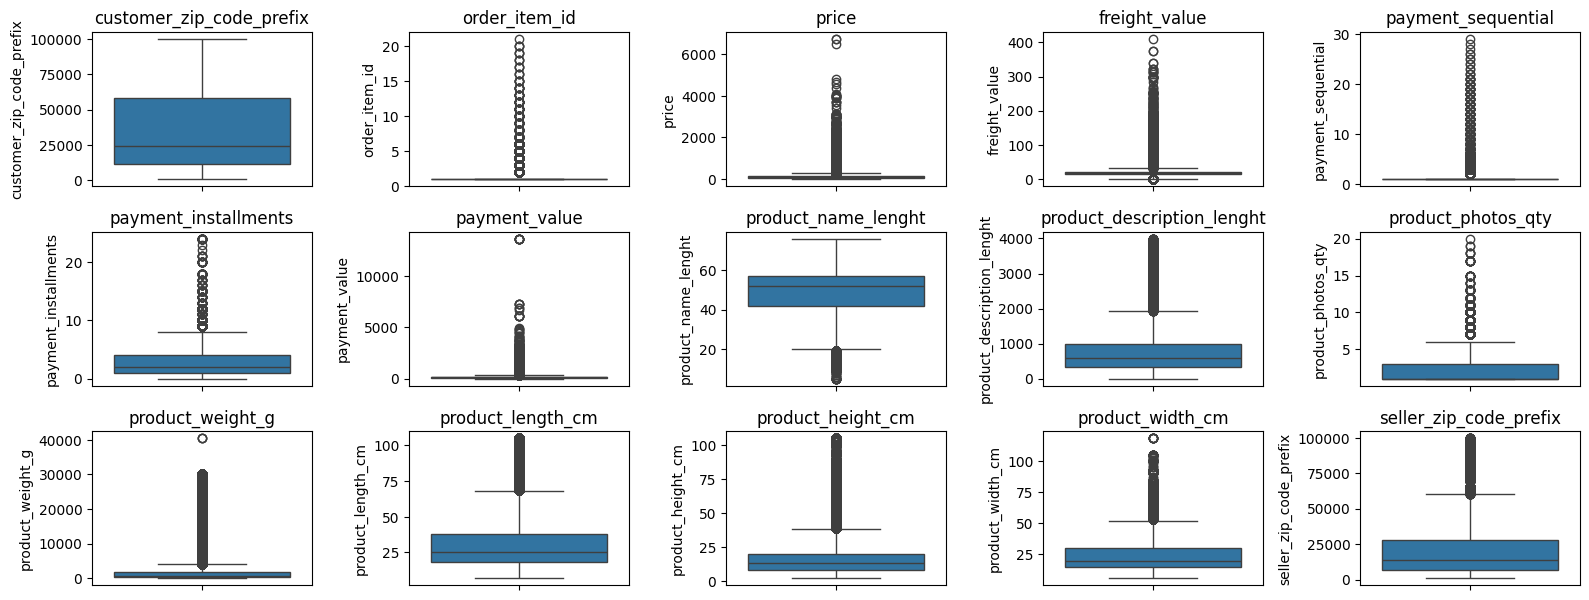

In [ ]:
plt.figure(figsize=(16,34))
for i, coloumn in enumerate(df_order.select_dtypes(include=['number']).columns):
    plt.subplot(17, 5, i + 1)
    sns.boxplot(data=df_order, y=coloumn)
    plt.title(f'{coloumn}')
    plt.ylabel(coloumn)
plt.tight_layout()
plt.show()

- Data distribution for all variables tends to be uneven, some variables tend to be skewed right or skewed left.
- except *customer_zip_code_prefix* all variables have quite a lot of outlier values

### Cleaning Data

####Change the date column data type to datetime

Gunakan regex untuk mendapatkan pola nama kolom yang harus diganti data tipenya dengan tipe datetime

In [6]:
for column in df_order.columns:
  pattern = r"(date|timestamp)$"
  if re.search(pattern, column):
    df_order[column] = pd.to_datetime(df_order[column])

Convert column yang tidak terdeteksi regex

In [7]:
df_order['order_approved_at'] = pd.to_datetime(df_order['order_approved_at'])

In [ ]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    118434 non-null  object        
 1   customer_unique_id             118434 non-null  object        
 2   customer_zip_code_prefix       118434 non-null  int64         
 3   customer_city                  118434 non-null  object        
 4   customer_state                 118434 non-null  object        
 5   order_id                       118434 non-null  object        
 6   order_status                   118434 non-null  object        
 7   order_purchase_timestamp       118434 non-null  datetime64[ns]
 8   order_approved_at              118258 non-null  datetime64[ns]
 9   order_delivered_carrier_date   116360 non-null  datetime64[ns]
 10  order_delivered_customer_date  115037 non-null  datetime64[ns]
 11  

####Fill Null value

fill null value on product_category_name_english with "others"

In [8]:
df_order['product_category_name_english'].fillna("others", inplace = True)

<ipython-input-8-3e3f7024f05c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_order['product_category_name_english'].fillna("others", inplace = True)


Separate datasets according to the status order to be analyzed.

In [9]:
df_delivered = df_order[df_order['order_status'] == 'delivered']
df_shipped = df_order[df_order['order_status'] == 'shipped']
df_processing = df_order[df_order['order_status'] == 'processing']
df_approved = df_order[df_order['order_status'] == 'approved']
df_invoiced = df_order[df_order['order_status'] == 'invoiced']

######Handle null value untuk df_delivered

In [10]:
#Menghapus karna tidak ada payment method yang terdeteksi
df_delivered.dropna(subset=['payment_value'], inplace = True)

<ipython-input-10-a8ca36874027>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_delivered.dropna(subset=['payment_value'], inplace = True)


######Handle null value untuk df_shipped

In [11]:
df_shipped.dropna(subset=['price', 'order_id', 'seller_zip_code_prefix'], inplace=True)

<ipython-input-11-81ffdf3e3810>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shipped.dropna(subset=['price', 'order_id', 'seller_zip_code_prefix'], inplace=True)


######Handle null value untuk df_invoiced

In [12]:
df_invoiced.dropna(subset=['order_id', 'seller_id'], inplace=True)

<ipython-input-12-9a304ad7ee92>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_invoiced.dropna(subset=['order_id', 'seller_id'], inplace=True)


######Merge the datasets

In [13]:
df_shop = pd.concat([df_delivered, df_shipped, df_processing, df_approved, df_invoiced])

In [ ]:
df_shop.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1141.0,1.0,8683.0,54.0,64.0,31.0,8577.0,itaquaquecetuba,SP,office_furniture
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1002.0,3.0,10150.0,89.0,15.0,40.0,88303.0,itajai,SC,housewares
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,955.0,1.0,8267.0,52.0,52.0,17.0,8577.0,itaquaquecetuba,SP,office_furniture
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1066.0,1.0,12160.0,56.0,51.0,28.0,8577.0,itaquaquecetuba,SP,office_furniture
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,407.0,1.0,5200.0,45.0,15.0,35.0,14940.0,ibitinga,SP,home_confort


####Drop Columns

In [14]:
for column in df_shop.columns:
    pattern = r"^product"
    if re.search(pattern, column) and df_shop[column].isnull().any():
        df_shop.drop(columns=column, inplace=True)

In [15]:
df_shop.drop(columns=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'shipping_limit_date', 'freight_value', 'payment_installments'], inplace=True)

In [ ]:
df_shop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117028 entries, 0 to 118114
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    117028 non-null  object        
 1   customer_unique_id             117028 non-null  object        
 2   customer_zip_code_prefix       117028 non-null  int64         
 3   customer_city                  117028 non-null  object        
 4   customer_state                 117028 non-null  object        
 5   order_id                       117028 non-null  object        
 6   order_status                   117028 non-null  object        
 7   order_purchase_timestamp       117028 non-null  datetime64[ns]
 8   order_estimated_delivery_date  117028 non-null  datetime64[ns]
 9   order_item_id                  117028 non-null  float64       
 10  product_id                     117028 non-null  object        
 11  selle

**Insight:**
- Delete rows with invalid data, such as shipped data has a seller id but has no information about the seller.
- There are several products that do not have a category so they are combined and made into another category
- Removing all columns that are not needed for further analysis
- Outliers are not removed on price because it is related to the price of the category and not identified as an error or invalid input.

## Exploratory Data Analysis (EDA)

### Explore ...

######Amount of Users

In [16]:
active_cust = df_order.groupby(by="order_status").agg({
    "customer_id": "count",
}).sort_values(by="customer_id", ascending=False)

print("Number of Customers per Order Status:")
print(active_cust.sort_values('customer_id', ascending=False))

Number of Customers per Order Status:
              customer_id
order_status             
delivered          115038
shipped              1245
canceled              745
unavailable           650
processing            375
invoiced              373
created                 5
approved                3


######JUMLAH PEMBELI DAN PENJUAL PERKATEGORI SECARA KESELURUHAN (Termasuk kategori canceled, unavailable, dsb)

In [17]:
cust_per_category = df_order.groupby(by="product_category_name_english").agg({
    "customer_id": "nunique",
    "seller_id": "nunique",
}).sort_values(by="customer_id", ascending=False)

print("categories sorted by the highest number of customers:")
print(cust_per_category.sort_values('customer_id', ascending=False))
print("categories sorted by the highest number of sellers:")
print(cust_per_category.sort_values('seller_id', ascending=False))

categories sorted by the highest number of customers:
                               customer_id  seller_id
product_category_name_english                        
bed_bath_table                        9417        196
health_beauty                         8836        492
sports_leisure                        7720        481
computers_accessories                 6689        287
furniture_decor                       6449        370
...                                    ...        ...
arts_and_craftmanship                   23         13
la_cuisine                              13          2
cds_dvds_musicals                       12          1
fashion_childrens_clothes                8          4
security_and_services                    2          2

[72 rows x 2 columns]
categories sorted by the highest number of sellers:
                               customer_id  seller_id
product_category_name_english                        
health_beauty                         8836        492
sports_

**Insight:**
- Although it does not look 100% positively correlated, it can be seen that categories with a large number of customers have a large number of sellers and vice versa.
- Based on the highest number of customers, the bed_bath_table category is a category that has a lot of interest while the security and service category has the least interest from customers.

######Cust total_orders	and expenditure dari pelanggan aktif (df_shop)

In [18]:
customer_shop = df_shop.groupby(by=(["customer_unique_id"]), as_index=False).agg({
        'order_id': 'count',
        'price': 'sum',
        'payment_value': 'mean'
    }).fillna(0)

customer_shop.rename(columns={'order_id': 'total_orders', 'price': 'expenditure', 'payment_value': 'system_cost'}, inplace=True)
customer_shop['average_expenditure'] = customer_shop['expenditure'] / customer_shop['total_orders']
customer_shop['short_customer_id'] = customer_shop['customer_unique_id'].astype(str).str[:6]

customer_shop = customer_shop.sort_values('expenditure', ascending=False).head(10)

**Insight**
- This e-commerce has the highest total orders from one customer at 75 orders, with total revenue from this customer being 2847.78 and this customer spending 39.55 per order on average.

######Total Selling per category (dari pelanggan aktif (df_shop))

In [19]:
active_total_selling = df_shop.groupby(by="product_category_name_english").agg({
    "customer_id": "nunique",
    "price": ["max", "min", "mean", "sum", "std"]
}).reset_index()
print("active_total_selling based on amount of customers:")
print(active_total_selling.sort_values(by=("customer_id", "nunique"), ascending=False).head(10))
print("active_total_selling based on price:")
print(active_total_selling.sort_values(by=("price", "mean"), ascending=False).head(10))

active_total_selling based on amount of customers:
   product_category_name_english customer_id    price                    \
                                     nunique      max   min        mean   
7                 bed_bath_table        9399  1999.98  6.99   92.463058   
43                 health_beauty        8799  3124.00  1.20  130.305507   
66                sports_leisure        7673  4059.00  4.50  114.208073   
15         computers_accessories        6654  3699.99  3.90  116.307276   
39               furniture_decor        6425  1899.00  4.90   87.596731   
49                    housewares        5847  6735.00  3.06   90.444249   
71                 watches_gifts        5604  3999.90  8.99  201.670361   
69                     telephony        4183  2428.00  5.00   71.896699   
5                           auto        3872  2258.00  3.49  140.436552   
70                          toys        3855  1699.99  4.90  117.045773   

                            
           sum     

**Insight**
- The category with the most orders is bed_bath_table with 9399 orders, but the highest revenue is earned by the computer category with an average of 1103.69 per order.
- From the table, there is an indication that the relationship between the number of orders and the average price per category is inversely proportional. the more expensive an item is, the fewer orders will be made and vice versa.

######Cust Payment Type

In [20]:
payment_customer_count = df_shop.groupby('payment_type').agg({
    "customer_unique_id": "nunique"
}).sort_values(by=("customer_unique_id"), ascending=False)
payment_customer_count.head()

,customer_unique_id
payment_type,
credit_card,73267
boleto,19052
voucher,3654
debit_card,1500


In [21]:
payment_customer_type = df_shop.groupby(['payment_type', 'payment_sequential', 'order_item_id'])['customer_unique_id'].nunique().reset_index()
print(payment_customer_type.sort_values(by=("customer_unique_id"), ascending=False))


    payment_type  payment_sequential  order_item_id  customer_unique_id
21   credit_card                 1.0            1.0               73238
0         boleto                 1.0            1.0               19051
22   credit_card                 1.0            2.0                7359
64       voucher                 2.0            1.0                2586
1         boleto                 1.0            2.0                2041
..           ...                 ...            ...                 ...
101      voucher                10.0            3.0                   1
104      voucher                11.0            3.0                   1
107      voucher                12.0            3.0                   1
110      voucher                13.0            3.0                   1
142      voucher                29.0            1.0                   1

[143 rows x 4 columns]


In [22]:
payment_customer_type[payment_customer_type['payment_sequential']==1.0].groupby('order_item_id')['customer_unique_id'].sum()

,customer_unique_id
order_item_id,
1.0,95229
2.0,9614
3.0,2235
4.0,933
5.0,438
6.0,247
7.0,58
8.0,36
9.0,28


In [23]:
# Group by 'order_id' and 'order_item_id', then aggregate 'payment_type' as a list
payment_combinations = df_shop.groupby(['order_id', 'order_item_id'])['payment_type'].agg(lambda x: ', '.join(x)).reset_index()

# 2. Rename columns for clarity
payment_combinations.columns = ['order_id', 'order_item_id', 'payment_methods_combined']

# 3. Filter orders with two or more payment methods using str.contains(',')
multi_payment_combinations = payment_combinations[payment_combinations['payment_methods_combined'].str.contains(',')]

# 4. Show the first few rows of orders with multiple payment methods
print("Orders with 2 or more payment methods combined for the same order_id and order_item_id:")
multi_payment_combinations.head(10)


Orders with 2 or more payment methods combined for the same order_id and order_item_id:


,order_id,order_item_id,payment_methods_combined
38,0016dfedd97fc2950e388d2971d718c7,1.0,"voucher, credit_card"
79,002f19a65a2ddd70a090297872e6d64e,1.0,"voucher, voucher"
179,0071ee2429bc1efdc43aa3e073a5290e,1.0,"voucher, voucher"
237,009ac365164f8e06f59d18a08045f6c4,1.0,"voucher, voucher, credit_card, voucher, vouche..."
280,00b4a910f64f24dbcac04fe54088a443,1.0,"voucher, credit_card"
299,00bd50cdd31bd22e9081e6e2d5b3577b,1.0,"voucher, voucher, credit_card"
308,00c405bd71187154a7846862f585a9d4,1.0,"voucher, voucher, voucher, voucher, voucher, c..."
321,00c95282163553a982f38481f9488481,1.0,"credit_card, voucher, voucher, voucher"
369,00e6bc6b166eb28b4502c1cad4457248,1.0,"credit_card, voucher"
516,013037c3f1773cc8fdbaf8ff54d8013b,1.0,"credit_card, voucher"


In [24]:
multi_payment_combinations.shape[0]

3268

**Insight**
- most customers use credit cards when shopping
- there are 3268 customers who combine payment methods when shopping

## Visualization & Explanatory Analysis

### Pertanyaan 1: What are the behaviors, carachteristic, transaction patterns of customers, particularly those with active orders, in relation to payment methods and product categories on the e-commerce platform?

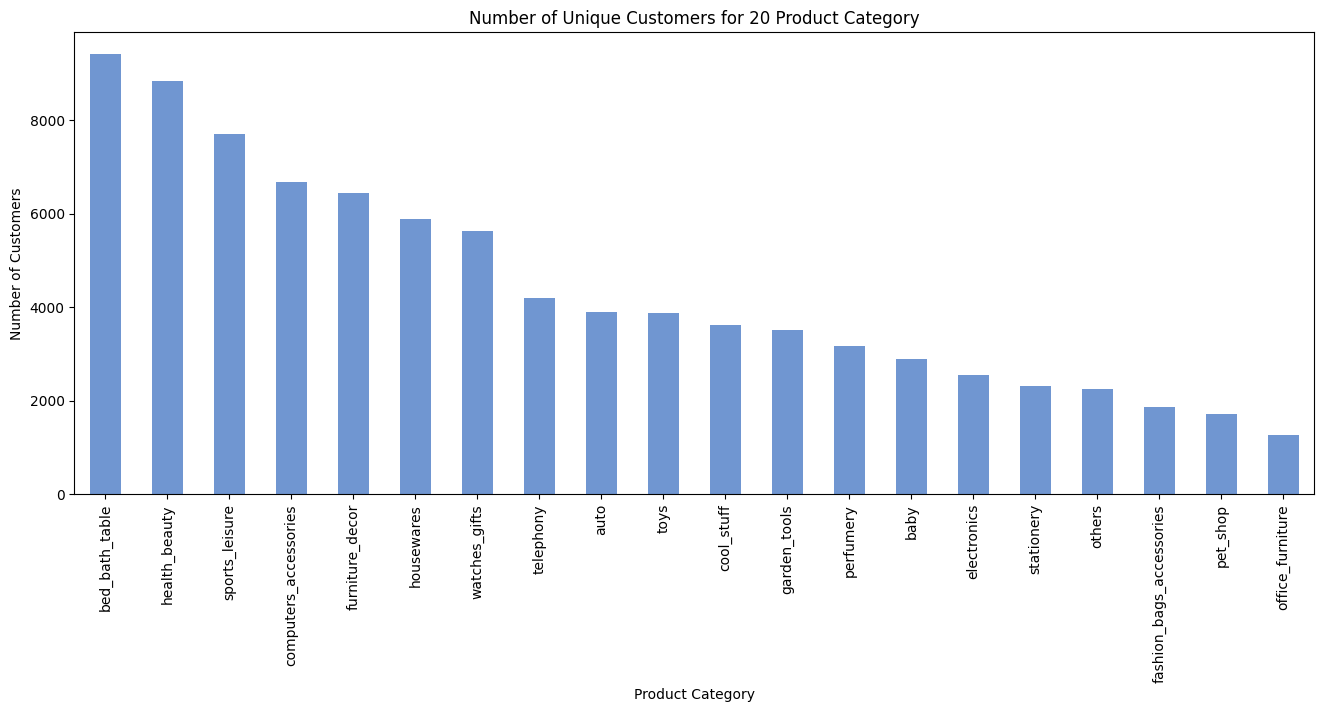

In [25]:
# Plotting the number of customers per category
plt.figure(figsize=(16, 6))
bars = cust_per_category['customer_id'].head(20)
bars.plot(kind='bar', color='#7096D1')

plt.title('Number of Unique Customers for 20 Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='None', alpha=1)

plt.show()


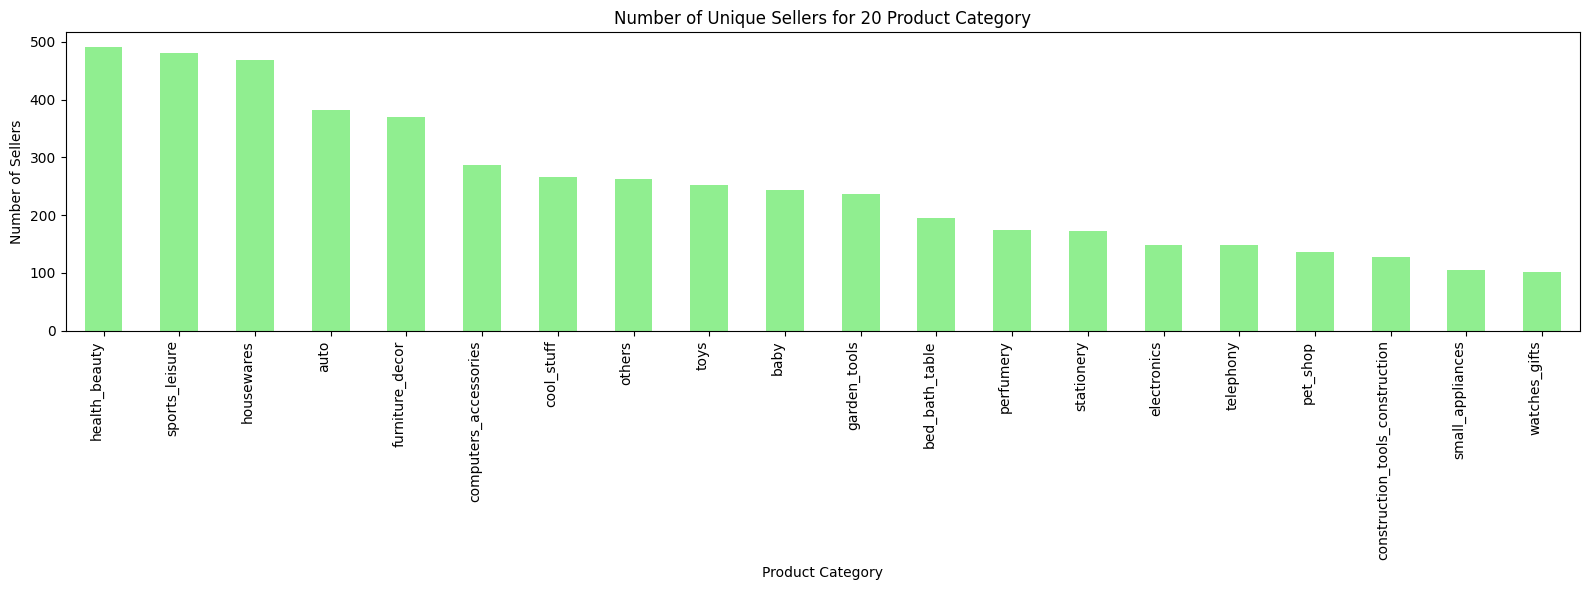

In [28]:
# Plotting the number of sellers per category
plt.figure(figsize=(16, 6))
cust_per_category.sort_values(by="seller_id", ascending=False)['seller_id'].head(20).plot(kind='bar', color='lightgreen')

plt.title('Number of Unique Sellers for 20 Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Sellers')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='None', alpha=1)

plt.tight_layout()
plt.show()


<ipython-input-27-d821ab419207>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=active_cust['customer_id'], y=active_cust.index, palette=colors)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When groupin

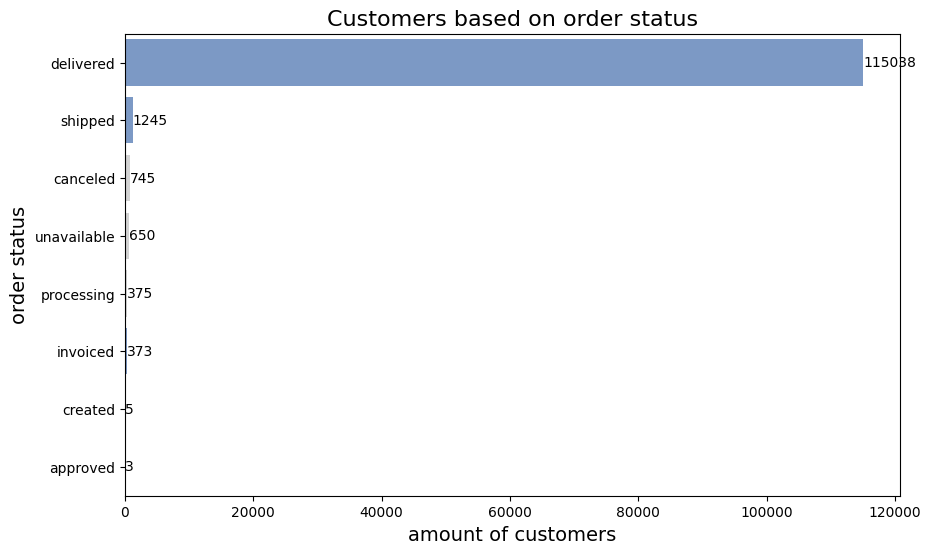

In [27]:
plt.figure(figsize=(10, 6))

colors = ['#7096D1' if status in ['delivered', 'approved', 'invoiced', 'shipped'] else '#D3D3D3' for status in active_cust.index]

sns.barplot(x=active_cust['customer_id'], y=active_cust.index, palette=colors)

plt.title('Customers based on order status', fontsize=16)
plt.xlabel('amount of customers', fontsize=14)
plt.ylabel('order status', fontsize=14)

for index, value in enumerate(active_cust['customer_id']):
    plt.text(value, index, str(value), va='center')

plt.show()


######Visualisasi Cust total_orders	and expenditure

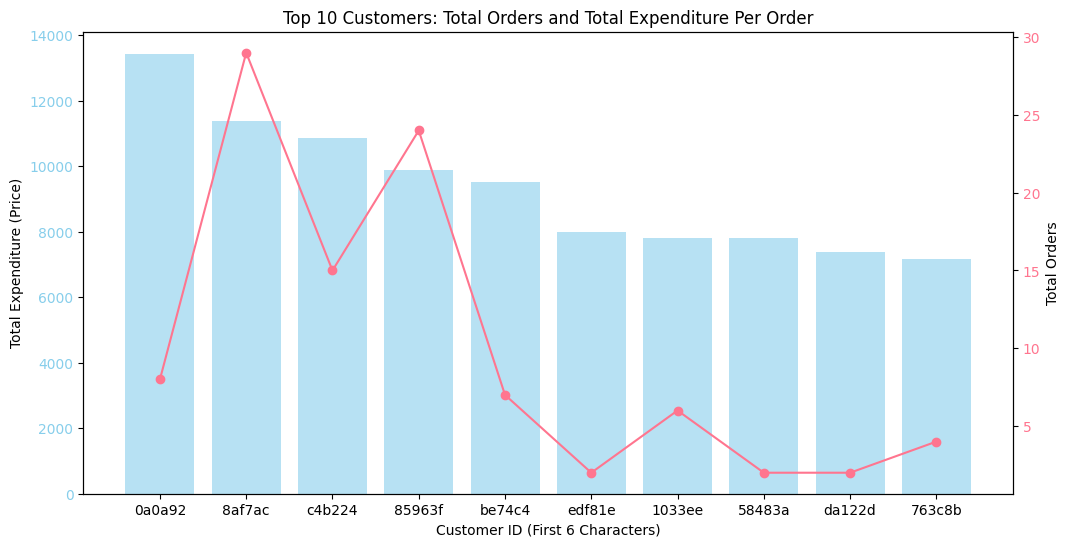

In [29]:
#Bar plot
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(customer_shop['short_customer_id'],  customer_shop['expenditure'], color='skyblue', alpha=0.6, label='Total Orders')
ax1.set_xlabel('Customer ID (First 6 Characters)')
ax1.set_ylabel('Total Orders', color='black')
ax1.set_ylabel('Total Expenditure (Price)', color='black')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax2 = ax1.twinx()
ax2.plot(customer_shop['short_customer_id'], customer_shop['total_orders'], color='#FF758F', marker='o', label='Total Expenditure')
ax2.set_ylabel('Total Orders', color='black')
ax2.tick_params(axis='y', labelcolor='#FF758F')

plt.title('Top 10 Customers: Total Orders and Total Expenditure Per Order')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight**
- The user with the most orders is not necessarily the user with the highest  spend

<ipython-input-30-b1bef52c76fc>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tupl

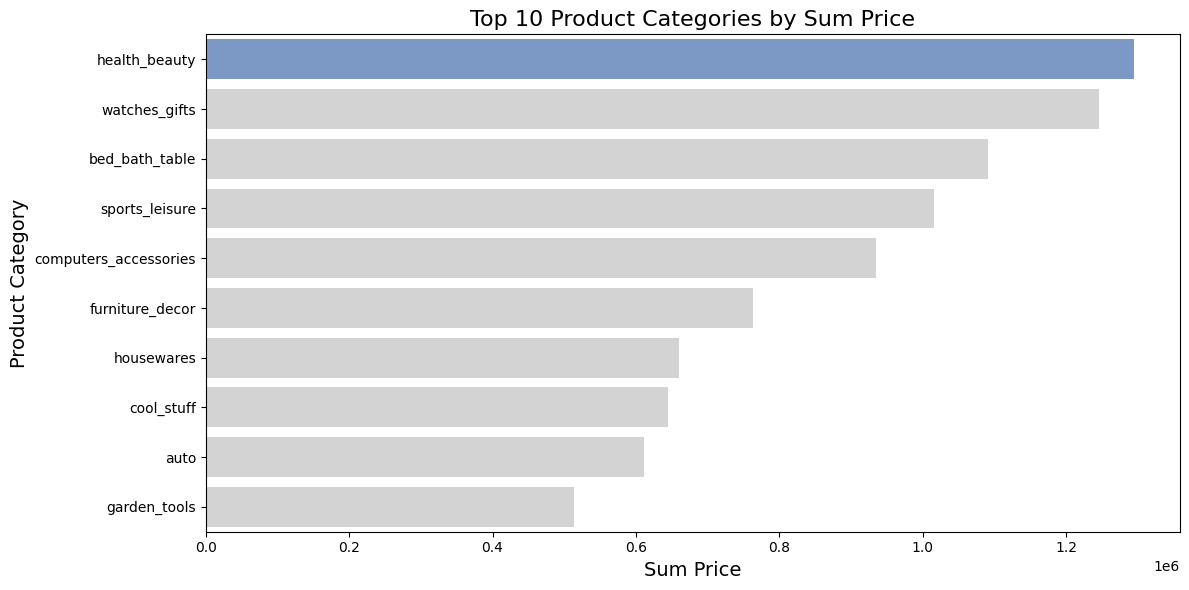

In [30]:
# Sort by mean price
sorted_selling = active_total_selling.sort_values(by=("price", "sum"), ascending=False).head(10)
colors_ = ["#7096D1", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(
    y="product_category_name_english",
    x=("price", "sum"),
    data=sorted_selling,
    palette=colors_
)
plt.title('Top 10 Product Categories by Sum Price', fontsize=16)
plt.xlabel('Sum Price', fontsize=14)
plt.ylabel('Product Category', fontsize=14)
plt.tight_layout()
plt.show()

#####Combination Payment Method

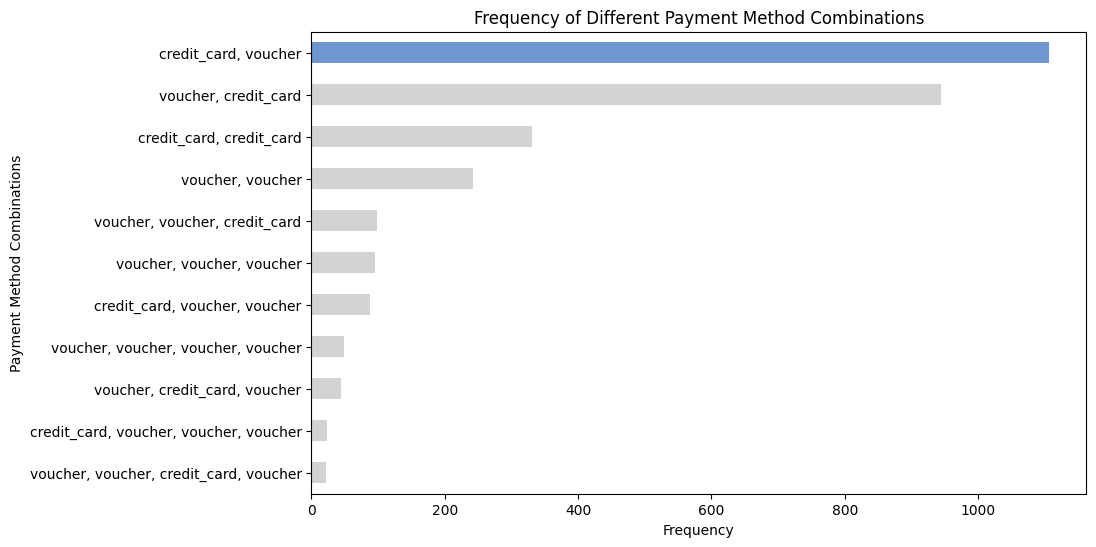

In [31]:
payment_combination_counts = multi_payment_combinations['payment_methods_combined'].value_counts()

filtered = payment_combination_counts[payment_combination_counts > 20]
colors = ["#7096D1", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

plt.figure(figsize=(10, 6))
filtered.plot(kind='barh', color=colors)
plt.xlabel('Frequency')
plt.ylabel('Payment Method Combinations')
plt.title('Frequency of Different Payment Method Combinations')
plt.gca().invert_yaxis()
plt.show()


**Insight**
- The credit card payment method accompanied by a voucher is a combined method that users often use to pay for an item on their order.

### Pertanyaan 2: What are the observed trends and patterns in sales growth across various product categories within the e-commerce sector during the specified analysis period?

######buyer per month

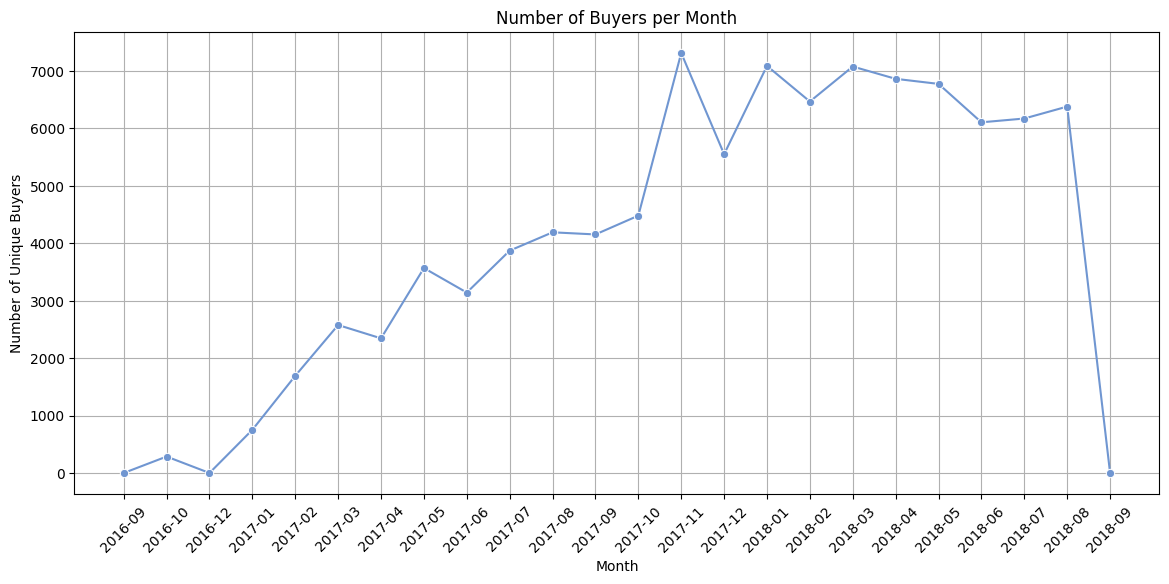

In [32]:
df_shop['purchase_month'] = df_shop['order_purchase_timestamp'].dt.to_period('M')
buyers_per_month = df_shop.groupby('purchase_month')['customer_unique_id'].nunique()
plt.figure(figsize=(14, 6))
sns.lineplot(x=buyers_per_month.index.astype(str),  y=buyers_per_month.values, marker='o', color="#7096D1")
plt.title('Number of Buyers per Month')
plt.xlabel('Month')
plt.ylabel('Number of Unique Buyers')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
print(buyers_per_month)

purchase_month
2016-09       1
2016-10     287
2016-12       1
2017-01     753
2017-02    1693
2017-03    2577
2017-04    2345
2017-05    3569
2017-06    3142
2017-07    3872
2017-08    4191
2017-09    4154
2017-10    4481
2017-11    7313
2017-12    5551
2018-01    7088
2018-02    6468
2018-03    7077
2018-04    6863
2018-05    6775
2018-06    6106
2018-07    6172
2018-08    6380
2018-09       1
Freq: M, Name: customer_unique_id, dtype: int64


cust order and spending per month

In [33]:
unique_customers_per_month = df_shop.groupby('purchase_month')['customer_unique_id'].nunique()

average_orders_per_customer_per_month = df_shop.groupby('purchase_month')['order_id'].count() / unique_customers_per_month
average_spend_per_customer_per_month = df_shop.groupby('purchase_month')['price'].sum() / unique_customers_per_month

print("average_orders_per_customer_per_month", average_orders_per_customer_per_month.sum()/average_orders_per_customer_per_month.shape[0])
print("average_spend_per_customer_per_month", average_spend_per_customer_per_month.sum()/average_orders_per_customer_per_month.shape[0])


average_orders_per_customer_per_month 1.23188317436785
average_spend_per_customer_per_month 139.45318806325312


######buyer per category per month

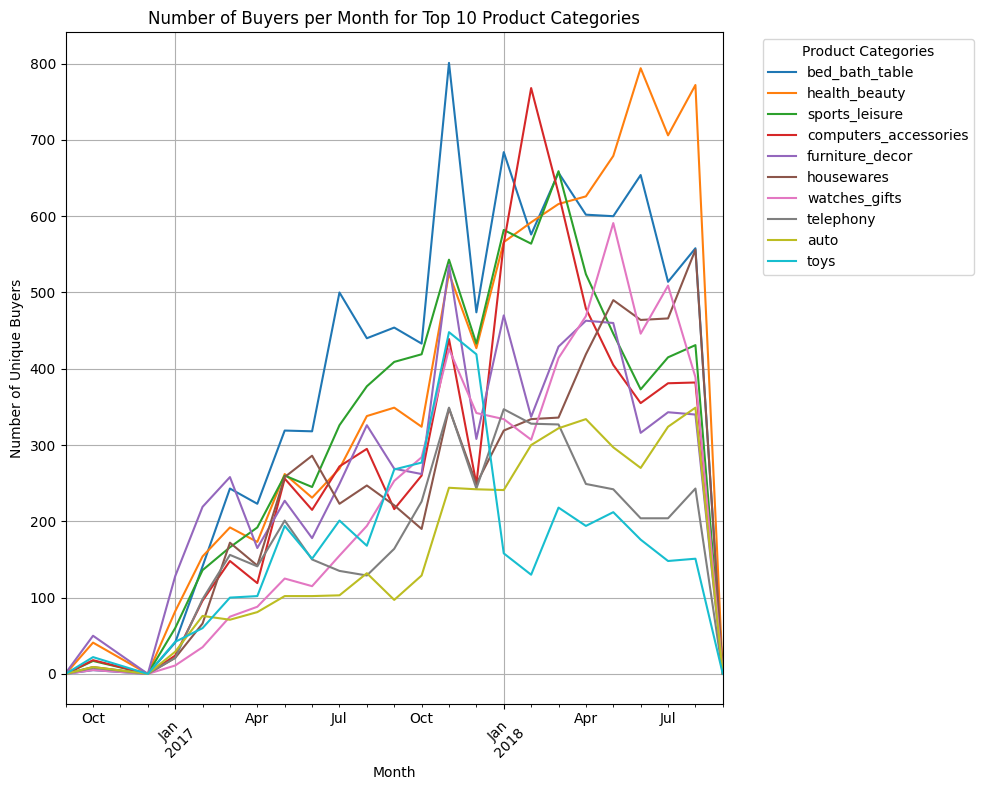

In [34]:
# Group by purchase month and product category, counting unique customers
buyers_per_month_category = df_shop.groupby(['purchase_month', 'product_category_name_english'])['customer_unique_id'].nunique()
buyers_per_month_category = buyers_per_month_category.unstack().fillna(0)

# Select the top 20 categories based on total unique buyers
buyers_per_month_category = buyers_per_month_category[buyers_per_month_category.sum().nlargest(10).index]

# Plotting
plt.figure(figsize=(10, 8))
buyers_per_month_category.plot(kind='line', marker='None', ax=plt.gca())
plt.title('Number of Buyers per Month for Top 10 Product Categories')
plt.xlabel('Month')
plt.ylabel('Number of Unique Buyers')
plt.xticks(rotation=45)
plt.grid()
plt.legend(title='Product Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


######buyer per hours

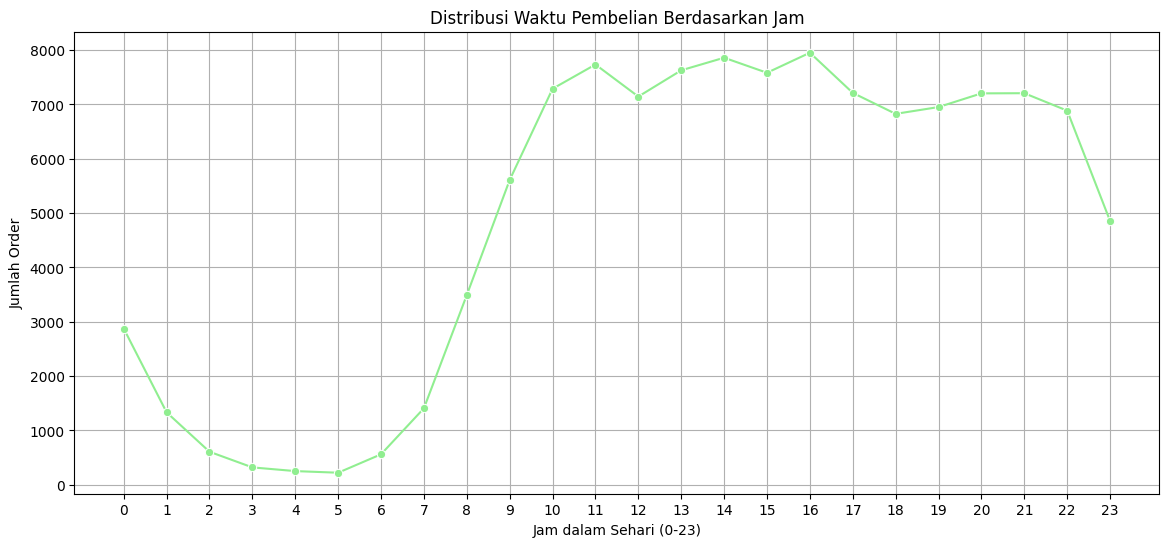

In [35]:
df_shop['purchase_hour'] = df_shop['order_purchase_timestamp'].dt.hour
df_shop['purchase_minute'] = df_shop['order_purchase_timestamp'].dt.minute
df_shop['purchase_second'] = df_shop['order_purchase_timestamp'].dt.second

orders_per_hour = df_shop.groupby('purchase_hour')['order_id'].count()

plt.figure(figsize=(14, 6))
sns.lineplot(x=orders_per_hour.index, y=orders_per_hour.values, marker='o', color='lightgreen')
plt.title('Distribusi Waktu Pembelian Berdasarkan Jam')
plt.xlabel('Jam dalam Sehari (0-23)')
plt.ylabel('Jumlah Order')
plt.xticks(range(0, 24))
plt.grid()
plt.show()


**Insight:**
- Over the course of two years, from September 2016 to September 2018, there was a notable increase in the volume of orders placed through this e-commerce platform. The peak occurred in November 2017, with a total of 7,313 orders recorded. Following this peak, however, there was a consistent decline in the number of orders leading up to September 2018.

- Additionally, the data indicates that users tend to place the majority of their orders around 16:00. Conversely, there is a significant drop in order activity between 00:00 and 05:00, followed by a steady rise in orders from 05:00 to 11:00.

## Analisis Lanjutan (Opsional)

Through the application of RFM analysis, organizations can effectively pinpoint their most valuable clientele—specifically, those exhibiting significant monetary contributions, frequent purchasing behavior, and recent transaction activity. This strategic approach enables companies to prioritize the cultivation of relationships with these key customers.

In [36]:
# Group by customer and aggregate the data
rfm_df = df_shop.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
})

# Rename columns to match RFM terminology
rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# Calculate Recency (days since last order)
recent_date = df_shop["order_purchase_timestamp"].max()
rfm_df["recency"] = (recent_date - rfm_df["max_order_timestamp"]).dt.days

# Drop the `max_order_timestamp` as it's no longer needed
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

print(rfm_df.sort_values(by = 'recency', ascending = False).head())


                            customer_id  frequency  monetary  recency
68296  b7d76e111c89f7ebf14761390f0f7d17          1     72.89      728
52319  8d3a54507421dbd2ce0a1d58046826e0          1    119.90      699
36463  61db744d2f835035a5625b59350c6b63          1     36.49      699
6331   10e89fd8e5c745f81bec101207ba4d7d          1     74.90      699
50298  87776adb449c551e74c13fc34f036105          1     29.99      699


<ipython-input-37-8977fc8ac040>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="short_customer_id", data=rfm_df.sort_values(by="recency", ascending=False).head(5), palette=colors, ax=ax[0])
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dis

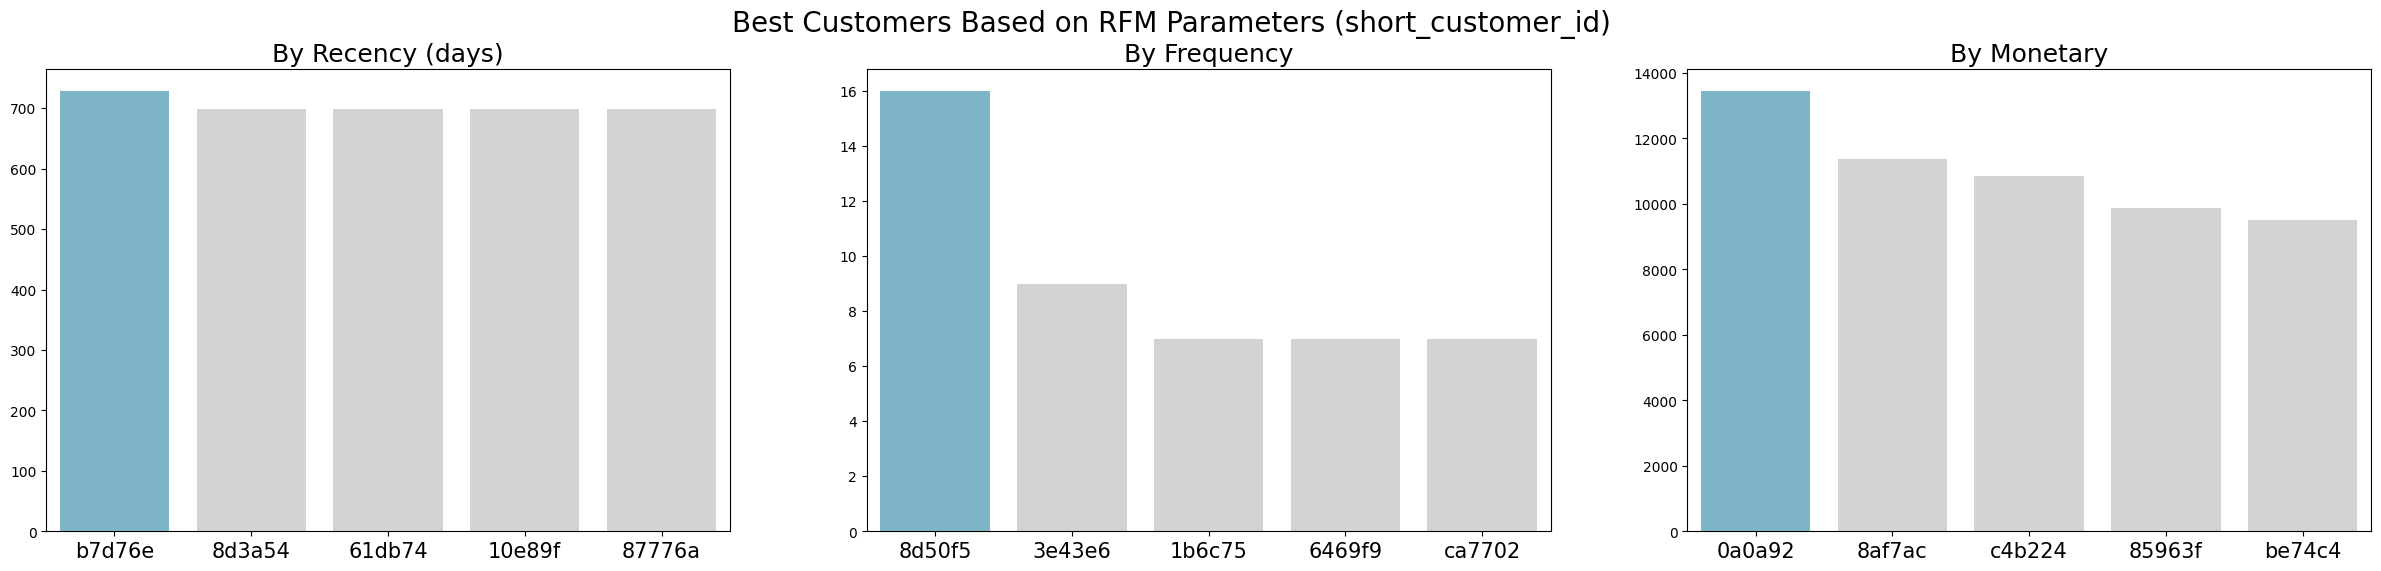

In [37]:
# Shorten the index of rfm_df (first 6 characters of customer_id)
rfm_df['short_customer_id'] = rfm_df['customer_id'].astype(str).str[:6]

# Plotting
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Recency Plot
sns.barplot(y="recency", x="short_customer_id", data=rfm_df.sort_values(by="recency", ascending=False).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', labelsize=15)

# Frequency Plot
sns.barplot(y="frequency", x="short_customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15)

# Monetary Plot
sns.barplot(y="monetary", x="short_customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15)

# Set the title for the whole plot
plt.suptitle("Best Customers Based on RFM Parameters (short_customer_id)", fontsize=20)
plt.show()


**Goals** Determine the Last Transaction Date, Purchase Frequenc, and Monetary Spending
1. Last Transaction Date:
    A notable number of customers have not engaged in any transactions for nearly two years or have not returned since their last purchase. This trend suggests that a considerable segment of the customer base may be inactive, indicating a potential necessity for strategies aimed at re-engaging these individuals.

2. Purchase Frequency:

    The peak purchase frequency observed for an individual customer in recent months is 16 transactions. This finding highlights the presence of highly engaged customers, who may constitute a critical demographic for targeted marketing initiatives.

3. Monetary Spending:

    The highest expenditure recorded by a single customer in recent months amounts to 14,000. This observation underscores the existence of customers with substantial spending capabilities, thereby presenting opportunities for implementing upselling or cross-selling strategies.


## Conclusion

- Conclution pertanyaan 1 : What are the behaviors, carachteristic, transaction patterns of customers, particularly those with active orders, in relation to payment methods and product categories on the e-commerce platform?
---
In summary, Customers with active orders prefer to buy product from the bed_bath_table category, this category consistently ranks as the most ordered category, irrespective of the status of orders. This is succeeded by the health beauty, sports leisure, and computer_accessories categories, indicating that the user demographic of this e-commerce platform primarily consists of individuals in their productive years. Customers with active order statuses—such as delivered, shipped, or processing—typically place an order approximately once a month, with an average expenditure of 139.4. The majority of these customers prefer to utilize credit cards for payment, and when multiple payment methods are employed, they often combine credit cards with vouchers.

- Conclution pertanyaan 2: What are the observed trends and patterns in sales growth across various product categories within the e-commerce sector during the specified analysis period?
---
- The analysis of the data reveals that the current product categories do not exhibit a discernible pattern or trend. The diagram illustrates that the growth rates of each category are characterized by significant fluctuations. Nevertheless, categories such as bed_bath_table, health beauty, and sport leisure significantly contribute to the overall revenue.
- The peak number of orders was observed in November 2017, reaching a total of 7,313. This surge likely indicates the presence of appealing shopping opportunities for consumers. Nevertheless, following this peak, there was a consistent decrease in order volume until September 2018, suggesting a necessity to reassess marketing approaches and customer engagement strategies to maintain growth.
- Additionally, an examination of temporal patterns reveals that users exhibit heightened activity in order placement throughout the day, particularly at 4 PM. The interval from midnight to 5 AM is characterized by a notable decline in shopping engagement, which subsequently rises from 5 AM to 11 AM. This observation underscores a distinct trend in consumer shopping behavior, suggesting that the majority of individuals prefer to shop post-work. Consequently, this presents a strategic opportunity to implement more assertive promotional efforts during these peak periods to enhance sales outcomes.

- Analisis Lanjutan
---
Through the application of RFM analysis, organizations can effectively pinpoint their most valuable clientele—specifically, those exhibiting significant monetary contributions, frequent purchasing behavior, and recent transaction activity. This strategic approach enables companies to prioritize the cultivation of relationships with these key customers.